# Installing z-3

In [1]:
! pip install z3-solver

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 69.1 MB/s eta 0:00:00


# Importing Libraries

In [2]:
import time
import numpy as np
from z3 import *
# from itertools import combinations, product
import re
from collections import defaultdict
from typing import Union
import ast
import copy

# Setting configurations

Setting z3 solver parameters to possible enhance performance.

In [3]:
set_param('parallel.enable', True) # This will enable parallel processing in z3 if possible
set_param('parallel.threads.max', 32)
set_param('sat.local_search_threads', 3)
set_param('sat.threads', 3)
# set_param('verbose', 10) # This lets solver know that the user wants to know the current status of the solver

# Helper function

In [4]:
def bind(vars : list[str]) -> tuple[dict[str, IntNumRef], dict[str, IntNumRef]]:
  z3_vars = {}
  z3_vars_primes = {}
  for var in vars:
    z3_vars[f'{var}'] = Int(f'{var}')
    z3_vars_primes[f'{var}'] = Int(f'_{var}')

  return z3_vars, z3_vars_primes

# Parser

In [5]:
import ast

z3_ops = {
    ast.Add: lambda a, b: a + b,
    ast.Sub: lambda a, b: a - b,
    ast.Mult: lambda a, b: a * b,
    ast.Div: lambda a, b: a / b,
    ast.Mod: lambda a, b: a % b,
    ast.Pow: lambda a, b: a ** b,

    ast.Eq: lambda a, b: a == b,
    ast.NotEq: lambda a, b: a != b,
    ast.Lt: lambda a, b: a < b,
    ast.LtE: lambda a, b: a <= b,
    ast.Gt: lambda a, b: a > b,
    ast.GtE: lambda a, b: a >= b,

    ast.BitAnd: lambda a, b: a & b,   # real bitwise AND
    ast.BitXor: lambda a, b: a ^ b,   # real XOR

    ast.USub: lambda a: -a,
    ast.Not: lambda a: Not(a),
}


def ast_to_z3(node, var_env):
    # numeric constants
    if isinstance(node, ast.Constant):
        val = node.value
        if isinstance(val, bool):
            return BoolVal(val)
        if isinstance(val, int):
            return IntVal(val)
        if isinstance(val, float):
            return RealVal(val)
        raise TypeError("Unsupported constant type")

    # variables
    if isinstance(node, ast.Name):
        if node.id not in var_env:
            var_env[node.id] = Int(node.id)  # or dynamic type inference
        return var_env[node.id]

    # binary op
    if isinstance(node, ast.BinOp):
        left = ast_to_z3(node.left, var_env)
        right = ast_to_z3(node.right, var_env)
        fn = z3_ops.get(type(node.op))
        if fn is None:
            raise TypeError(f"Unsupported op: {ast.dump(node.op)}")
        return fn(left, right)

    # boolean op: "and", "or"
    if isinstance(node, ast.BoolOp):
        items = [ast_to_z3(v, var_env) for v in node.values]
        if isinstance(node.op, ast.And):
            return And(*items)
        if isinstance(node.op, ast.Or):
            return Or(*items)
        raise TypeError(f"Unsupported BoolOp: {ast.dump(node.op)}")

    # unary op
    if isinstance(node, ast.UnaryOp):
        fn = z3_ops.get(type(node.op))
        if fn is None:
            raise TypeError(f"Unsupported unary op: {ast.dump(node.op)}")
        return fn(ast_to_z3(node.operand, var_env))

    # chained comparisons
    if isinstance(node, ast.Compare):
        left = ast_to_z3(node.left, var_env)
        result = BoolVal(True)
        for op, comp in zip(node.ops, node.comparators):
            right = ast_to_z3(comp, var_env)
            fn = z3_ops[type(op)]
            result = And(result, fn(left, right))
            left = right
        return result

    raise TypeError(f"Unsupported node: {ast.dump(node)}")


Wrapper.

In [6]:
def parse_z3(expr: str, vars_dict: dict[str, object]):
    tree = ast.parse(expr, mode='eval').body
    return ast_to_z3(tree, vars_dict)

In [7]:
var_dict = {}
expr = "x==0 and x+y<100 and not (x == 10)"

parse_z3(expr, var_dict)



And(And(True, 0 == x),
    And(True, 100 > x + y),
    Not(And(True, 10 == x)))

# Clauses

In [8]:
class Clause:
  def __init__(self, expr : str):
    self.expr = expr

  def get_clause(self, var_dict : dict):
    z3_clause = parse_z3(self.expr, var_dict)
    return z3_clause
  def negate(self):
    self.expr = f"not ({self.expr})"
    return self

# Frames

Frames are a set of clauses.

In [9]:
class Frame:
  def __init__(self, clauses : list[Clause]):
    self.clauses : list[Clause] = clauses
    # Set of blocked cubes
    self.blocked = []

  def add_clause(self, clause : Clause):
    self.clauses.append(clause)

  def block_cube(self, value_s):
    self.blocked.append(value_s)

  def get_clause(self, var_dict : dict):
    # print(f"=={self.clauses}==")
    return And([clause.get_clause(var_dict) for clause in self.clauses])

  def get_clauses_list(self) -> list[Clause]:
    return self.clauses.copy()

class Frames:
  def __init__(self, init : str, P : str):
    # Initialize later frames with P
    self.init = init
    self.k = 1
    self.P = P
    self.frames = [] # list of Frames

  def add_frame(self):
    # initialize a frame with P and add it to the frame list
    self.k = self.k + 1
    self.frames.append(Frame([Clause(self.P)]))

  def get_frame(self, i : int, var_dict : dict):
    if i == 0:
      return parse_z3(self.init, var_dict)
    return self.frames[i - 1].get_clause(var_dict)

  def get_P(self, var_dict : dict):
    # Remove _ from primes
    # var_dict_ = {}
    # for key in var_dict:
    #   var_dict_[key[1:]] = var_dict[key]

    return parse_z3(self.P, var_dict)

  def add_clause_to_frame(self, k : int, clause : str| Clause, invert = False, check = False, variables : list[str] = []):
    if check and variables:
      s = Solver()
      z3_vars, _ = bind(variables)
      s.add(Not(Implies(self.get_frame(k, z3_vars), Clause(clause).get_clause(z3_vars) if isinstance(clause, str) else clause.get_clause(z3_vars))))

      if s.check() == unsat:
        return False

    if isinstance(clause, Clause):
      self.frames[k - 1].add_clause(clause if not invert else clause.negate())
    elif isinstance(clause, str):
      self.frames[k - 1].add_clause(Clause(clause) if not invert else Clause(clause).negate())
    else:
      print('Cannot add!')

  def block_clause_in_frame(self, k : int, clause : str | Clause, value_s):
    if k == 0:
      return False # Cannot block in frame 0

    flag = True
    for b in self.frames[k - 1].blocked:
      flag_t = True # clause and b are same
      for key in b:
        # print(type(b[k].as_long()))
        # print(type(value_s[k].as_long()))
        if b[key].as_long() != value_s[key].as_long():
          flag_t = False
          break
      if flag_t:
        # clause is already blocked
        flag = False

    if flag:
      self.add_clause_to_frame(k, clause, False)
      self.frames[k - 1].block_cube(value_s)
      return True
    return False

  def __getitem__(self, k : int):
    if k == 0:
      return Clause(self.init).get_clause()

    return self.frames[k - 1]



# PDR

## Extend frontier

In [10]:
def extendFrontier(variables : list[str], T, frames : Frames, k : int):
  while True:
    s = Solver()
    z3_vars, z3_vars_primes = bind(variables)
    s.add(frames.get_frame(k, z3_vars))
    s.add(T(z3_vars, z3_vars_primes))
    # Not p'
    # This is wrong ?
    s.add(Not(frames.get_P(z3_vars_primes)))

    if s.check() == sat:
      values = {}
      m = s.model()
      for v in z3_vars :
        values[v] = m[z3_vars[v]]

      if not removeCTI(variables, k, frames, T, values):
        # z3_vars is cube s.
        return False
    else:
      break

  return True

## Remove CTI

In [11]:
def removeCTI(variables : list[str], k : int, frames : Frames, T, values_s : dict):
  print('CTI, k :', values_s, k)
  s = Solver()
  # s and s'
  z3_vars, z3_vars_primes = bind(variables)
  cube_s = And([z3_vars[v] == values_s[v] for v in variables])

  if k == 0:
    s.push()
    s.add(frames.get_frame(0, z3_vars))
    s.add(cube_s)


    if s.check() == sat:
      return False

    s.pop()

  # s -> s' (here s' is s)
  cube_s_prime = And([z3_vars_primes[f"{v}"] == values_s[v] for v in variables])
  cube_s_str_not = ' or '.join([f'{v} != {values_s[v]}' for v in variables])
  cube_s_not = Clause(cube_s_str_not).get_clause(z3_vars)
  #Check if the CTI is already blocked
  if not frames.block_clause_in_frame(k, cube_s_str_not, values_s):
    print(f'Already Blocked {cube_s_not} in frame {k}')
    return True

  while True:
    s.push()

    s.add(cube_s_not)
    s.add(cube_s_prime)
    s.add(T(z3_vars, z3_vars_primes))
    s.add(frames.get_frame(k - 1, z3_vars))

    # print(1, cube_s_not)
    # print(2, cube_s_prime)
    # print(3, frames.get_frame(k - 1, z3_vars))


    for i in range(1, k):
      if frames.block_clause_in_frame(i, cube_s_str_not, values_s):
        print(f'Blocked {cube_s_not} in frame {i}')
      else:
        print(f'Already Blocked {cube_s_not} in frame {i}')
      # frames.add_clause_to_frame(i, cube_s_str_not)

    if s.check() == sat:
      # Get values of predecessors
      values = {}
      m = s.model()
      for v in variables :
        values[v] = m[z3_vars[v]]

      # print(f'predecessor = {values}')

      if not removeCTI(variables, k - 1, frames, T, values):
        # z3_vars is cube s.
        return False
    else:
      s.pop()
      break

    s.pop()

  return True



## Propagate clause

In [12]:
def propagate_clause(variables : list[str], frames : Frames, k : int, T):
  s = Solver()
  z3_vars, z3_vars_primes = bind(variables)
  count = 0

  for i in range(1, k + 1):
    for c in frames[i].get_clauses_list():
      # print('---------------------------')
      # print(i, frames.get_frame(i, z3_vars))
      # print(i, c.get_clause(z3_vars_primes))
      # print(T(z3_vars, z3_vars_primes))
      # print('---------------------------')
      s.push()

      phi = And([T(z3_vars, z3_vars_primes), frames.get_frame(i, z3_vars), Not(c.get_clause(z3_vars_primes))])
      # s.add(Not(phi))
      s.add(phi)

      if s.check() == unsat:
        count = count + 1
        frames.add_clause_to_frame(i + 1, c, variables = variables, check = True)

      s.pop()

  print(f'Propagation report at Frame {k}: propagated {count} clauses to Frame {k + 1}')



## Main algorithm

In [13]:
def PDR(T, init : str, P : str, variables : list[str], propagate = True):
  frames = Frames(init, P)
  s = Solver()
  z3_vars = {}
  for vars in variables:
    z3_vars[vars] = Int(vars)

  s.push()
  # print(Clause(P).get_clause(z3_vars))
  # print(Clause(init).get_clause(z3_vars))
  s.add(Clause(P).get_clause(z3_vars))
  s.add(Clause(init).get_clause(z3_vars))


  if s.check() == unsat:
    return False

  s.pop()

  k = 0
  while True:
    print(f"k = {k}")
    frames.add_frame()
    if not extendFrontier(variables, T, frames, k):
      # print(frames[k - 1])
      print(f"k = {k}")
      return False

    if k > 0 and propagate:
     propagate_clause(variables, frames, k, T)

    # if k > 2:
    #   s.add(Not(Or(frames.get_frame(k, z3_vars) == frames.get_frame(k + 1, z3_vars), frames.get_frame(k - 1, z3_vars) == frames.get_frame(k, z3_vars))))
    # else:
    #   s.add(Not(frames.get_frame(k, z3_vars) == frames.get_frame(k + 1, z3_vars)))

    print(f"F_{k}>>>>", frames.get_frame(k, z3_vars))

    for i in range(0, k + 1):
      s.push()
      s.add(Not(frames.get_frame(i, z3_vars) == frames.get_frame(i + 1, z3_vars)))

      if s.check() == unsat:
        return simplify(frames.get_frame(i, z3_vars))
        # return frames.get_frame(i, z3_vars)
      s.pop()
    k = k + 1



  return False


# Example

Define $T$.

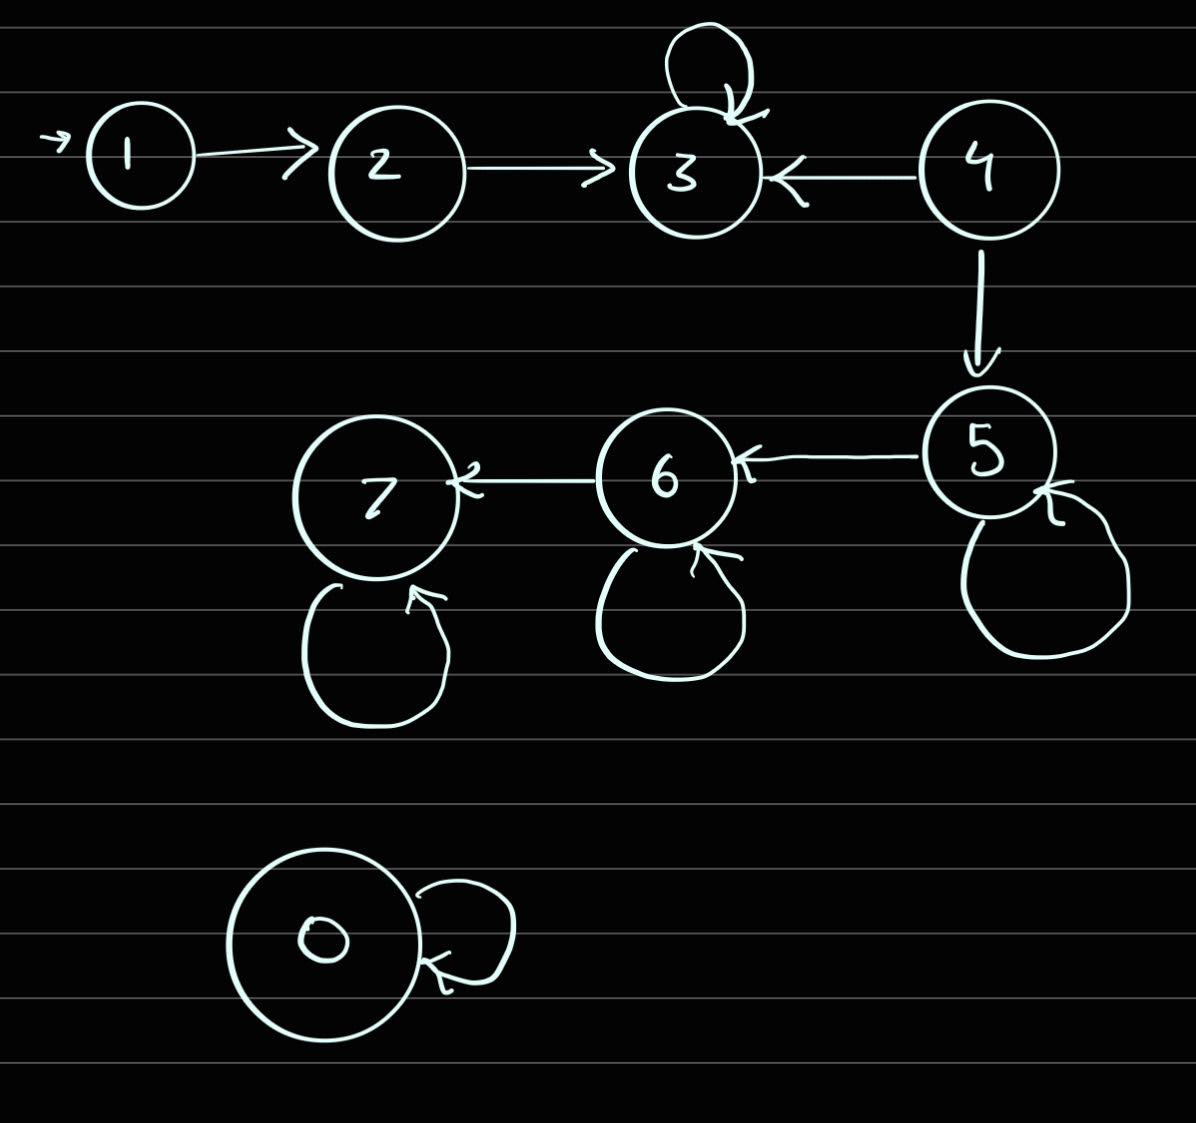

In [ ]:
def T(s, s_):
  return Or(And(s['x'] == 1, s_['x'] == 2), And(s['x'] == 2, s_['x'] == 3), And(s['x'] == 4, s_['x'] == 3), And(s['x'] == 4, s_['x'] == 5), And(s['x'] == 3, s_['x'] == 3),
            And(s['x'] == 5, s_['x'] == 6), And(s['x'] == 6, s_['x'] == 7), And(s['x'] == 5, s_['x'] == 5), And(s['x'] == 6, s_['x'] == 6), And(s['x'] == 7, s_['x'] == 7),
            And(s['x'] == 0, s_['x'] == 0))

Execute $PDR$.

In [ ]:
variables = ['x']
PDR(T, "x==1", "x>3", variables)

False

In [ ]:
variables = ['x']
# t = time.time()
PDR(T, "x==1", "x<=4", variables)
# print(time.time() - t)

k = 0
F_0>>>> And(True, 1 == x)
k = 1
CTI, k : {'x': 4} 1
Propagation report at Frame 1: propagated 2 clauses to Frame 2
F_1>>>> And(And(True, 4 >= x), And(True, 4 != x))


And(4 >= x, Not(4 == x))

Different $T$. Flip edge from 3 to 4 and add edge 5 to 0.

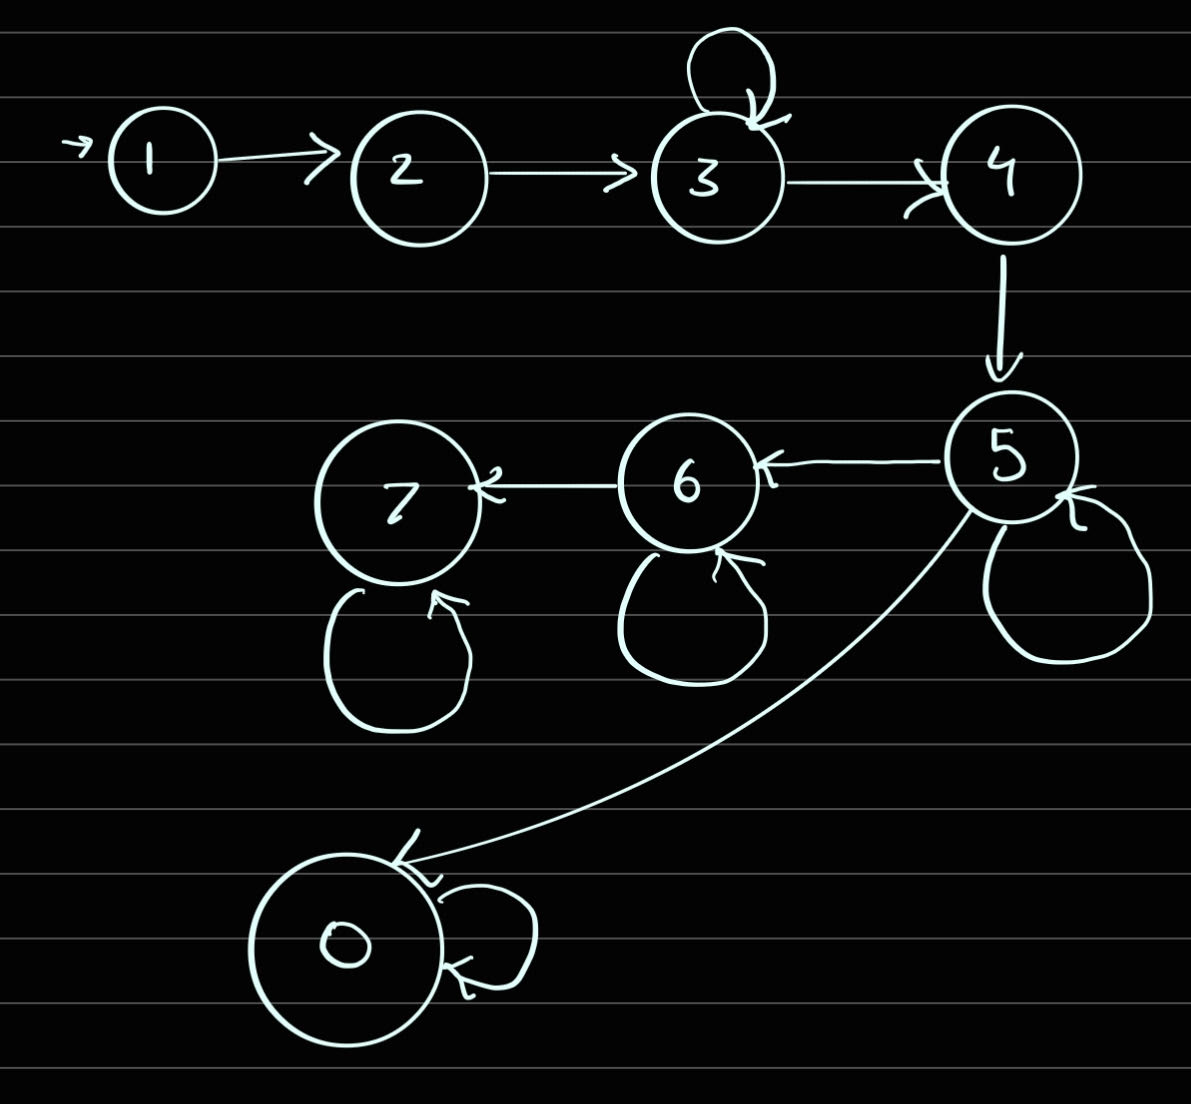

In [ ]:
def T(s, s_):
  return Or(And(s['x'] == 1, s_['x'] == 2), And(s['x'] == 2, s_['x'] == 3), And(s['x'] == 3, s_['x'] == 4), And(s['x'] == 4, s_['x'] == 5), And(s['x'] == 3, s_['x'] == 3),
            And(s['x'] == 5, s_['x'] == 6), And(s['x'] == 6, s_['x'] == 7), And(s['x'] == 5, s_['x'] == 5), And(s['x'] == 6, s_['x'] == 6), And(s['x'] == 7, s_['x'] == 7),
            And(s['x'] == 0, s_['x'] == 0), And(s['x'] == 5, s_['x'] == 0))

In [ ]:
variables = ['x']
PDR(T, "x==1", "x<=6 and x>0", variables)

k = 0
F_0>>>> And(True, 1 == x)
k = 1
CTI, k : {'x': 6} 1
CTI, k : {'x': 5} 1
Propagation report at Frame 1: propagated 2 clauses to Frame 2
F_1>>>> And(And(And(True, 6 >= x), And(True, 0 < x)),
    And(True, 6 != x),
    And(True, 5 != x))
k = 2
CTI, k : {'x': 5} 2
Already Blocked And(True, 5 != x) in frame 1
CTI, k : {'x': 4} 1
Already Blocked And(True, 5 != x) in frame 1
Propagation report at Frame 2: propagated 5 clauses to Frame 3
F_2>>>> And(And(And(True, 6 >= x), And(True, 0 < x)),
    And(True, 6 != x),
    And(True, 5 != x))
k = 3
CTI, k : {'x': 5} 3
Already Blocked And(True, 5 != x) in frame 1
Already Blocked And(True, 5 != x) in frame 2
CTI, k : {'x': 4} 2
Already Blocked And(True, 4 != x) in frame 1
CTI, k : {'x': 3} 1
Already Blocked And(True, 4 != x) in frame 1
Already Blocked And(True, 5 != x) in frame 1
Already Blocked And(True, 5 != x) in frame 2
Propagation report at Frame 3: propagated 9 clauses to Frame 4
F_3>>>> And(And(And(True, 6 >= x), And(True, 0 < x)),
    And

False

Using BitVectors.

In [ ]:
def T(s, _s):
  return Or(And(s['x2'] == 0, s['x1'] == 0, s['x0'] == 1 , _s['x2'] == 0, _s['x1'] == 1, _s['x0'] == 0 ), And(s['x2'] == 0, s['x1'] == 1, s['x0'] == 0 , _s['x2'] == 0, _s['x1'] == 0, _s['x0'] == 1 ), And(s['x2'] == 1, s['x1'] == 0, s['x0'] == 0 , _s['x2'] == 0, _s['x1'] == 1, _s['x0'] == 1 ), And(s['x2'] == 1, s['x1'] == 0, s['x0'] == 0 , _s['x2'] == 1, _s['x1'] == 0, _s['x0'] == 1 ), And(s['x2'] == 0, s['x1'] == 1, s['x0'] == 1 , _s['x2'] == 0, _s['x1'] == 1, _s['x0'] == 1 ),
            And(s['x2'] == 1, s['x1'] == 0, s['x0'] == 1 , _s['x2'] == 1, _s['x1'] == 1, _s['x0'] == 0 ), And(s['x2'] == 1, s['x1'] == 1, s['x0'] == 0 , _s['x2'] == 1, _s['x1'] == 1, _s['x0'] == 1 ), And(s['x2'] == 0, s['x1'] == 1, s['x0'] == 1 , _s['x2'] == 0, _s['x1'] == 1, _s['x0'] == 1 ), And(s['x2'] == 1, s['x1'] == 0, s['x0'] == 1 , _s['x2'] == 1, _s['x1'] == 0, _s['x0'] == 1 ), And(s['x2'] == 1, s['x1'] == 1, s['x0'] == 1 , _s['x2'] == 1, _s['x1'] == 1, _s['x0'] == 1 ),
            And(s['x2'] == 0, s['x1'] == 0, s['x0'] == 0 , _s['x2'] == 0, _s['x1'] == 0, _s['x0'] == 0 ))

In [ ]:
variables = ['x0', 'x1', 'x2']
PDR(T, "x0 == 1 and x1 == 0 and x2 == 0", "x2 == 0", variables)

k = 0
F_0>>>> And(And(True, 1 == x0),
    And(True, 0 == x1),
    And(True, 0 == x2))
k = 1
Propagation report at Frame 1: propagated 1 clauses to Frame 2
F_1>>>> And(And(True, 0 == x2))


0 == x2

In [ ]:
variables = ['x0', 'x1', 'x2']
PDR(T, "x0 == 1 and x1 == 0 and x2 == 1", "x2 == 0", variables)

False

In [ ]:
# 0 < x <= 4
variables = ['x0', 'x1', 'x2']
PDR(T, "x0 == 1 and x1 == 0 and x2 == 0", "(x2 == 0 and x1 == 0 and x0 == 1) or (x2 == 0 and x1 == 1 and x0 == 0) or (x2 == 0 and x1 == 1 and x0 == 1) or (x2 == 1 and x1 == 0 and x0 == 0)", variables)

k = 0
F_0>>>> And(And(True, 1 == x0),
    And(True, 0 == x1),
    And(True, 0 == x2))
k = 1
CTI, k : {'x0': 0, 'x1': 0, 'x2': 1} 1
Propagation report at Frame 1: propagated 2 clauses to Frame 2
F_1>>>> And(Or(And(And(True, 0 == x2),
           And(True, 0 == x1),
           And(True, 1 == x0)),
       And(And(True, 0 == x2),
           And(True, 1 == x1),
           And(True, 0 == x0)),
       And(And(True, 0 == x2),
           And(True, 1 == x1),
           And(True, 1 == x0)),
       And(And(True, 1 == x2),
           And(True, 0 == x1),
           And(True, 0 == x0))),
    Or(And(True, 0 != x0),
       And(True, 0 != x1),
       And(True, 1 != x2)))


And(Or(And(0 == x2, 0 == x1, 1 == x0),
       And(0 == x2, 1 == x1, 0 == x0),
       And(0 == x2, 1 == x1, 1 == x0),
       And(1 == x2, 0 == x1, 0 == x0)),
    Or(Not(0 == x0), Not(0 == x1), Not(1 == x2)))

## Propagation Clause is an optimization

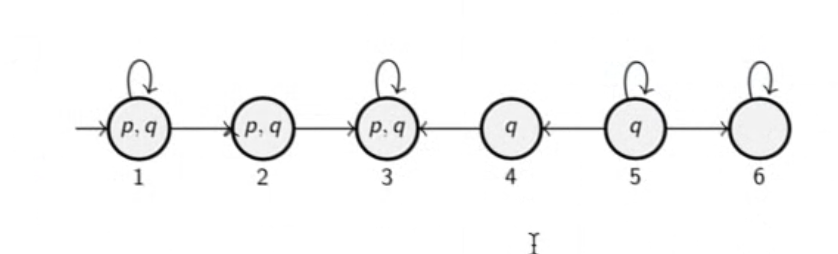

In [14]:
def T(s, s_):
  return Or(And(s['x'] == 1, s_['x'] == 2), And(s['x'] == 2, s_['x'] == 3), And(s['x'] == 3, s_['x'] == 3), And(s['x'] == 4, s_['x'] == 3), And(s['x'] == 5, s_['x'] == 4),
            And(s['x'] == 5, s_['x'] == 5), And(s['x'] == 6, s_['x'] == 6), And(s['x'] == 5, s_['x'] == 6))

In [16]:
variables = ['x']
PDR(T, "x==1", "x<=5", variables, False)

k = 0
F_0>>>> And(True, 1 == x)
k = 1
CTI, k : {'x': 5} 1
F_1>>>> And(And(True, 5 >= x), And(True, 5 != x))
k = 2
CTI, k : {'x': 5} 2
Already Blocked And(True, 5 != x) in frame 1
F_2>>>> And(And(True, 5 >= x), And(True, 5 != x))


And(5 >= x, Not(5 == x))

Propagation optimization.

In [ ]:
variables = ['x']
PDR(T, "x==1", "x<=5", variables)

k = 0
F_0>>>> And(True, 1 == x)
k = 1
CTI, k : {'x': 5} 1
Propagation report at Frame 1: propagated 2 clauses to Frame 2
F_1>>>> And(And(True, 5 >= x), And(True, 5 != x))


And(5 >= x, Not(5 == x))

## IC3 vs K-induction

Reference for k-induction: (Prof srivas slides).

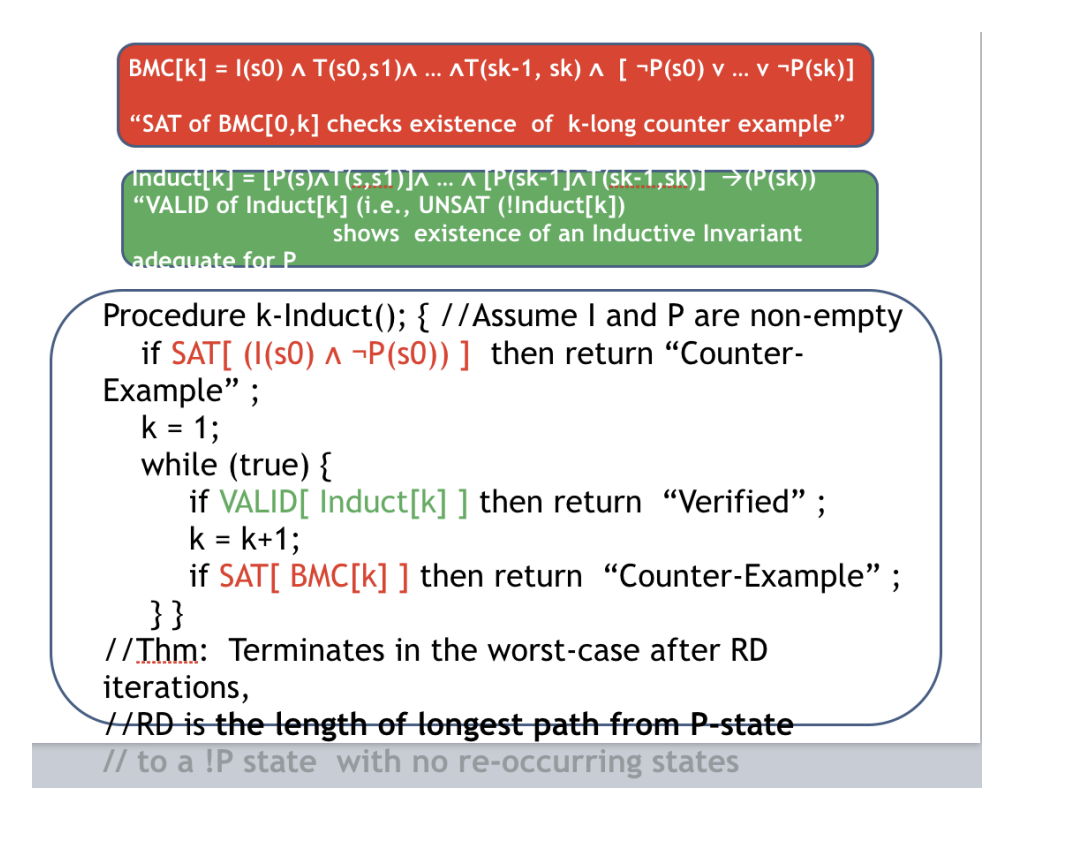

## Example is work under progress...

In [ ]:
def T(s, s_):
  return Or([And(s['x'] == i, s_['x'] == i + 1) for i in range(20)])
  # return Or(And(s['x'] == 1, s_['x'] == 2), And(s['x'] == 2, s_['x'] == 3), And(s['x'] == 3, s_['x'] ==4), And(s['x'] == 4, s_['x'] == 5), And(s['x'] == 5, s_['x'] == 6),
  #           And(s['x'] == 6, s_['x'] == 7), And(s['x'] == 7, s_['x'] == 8), And(s['x'] == 8, s_['x'] == 9))

In [ ]:
variables = ['x']
PDR(T, "x==1", "x<=6", variables)

k = 0
F_0>>>> And(True, 1 == x)
k = 1
CTI, k : {'x': 6} 1
Propagation report at Frame 1: propagated 1 clauses to Frame 2
F_1>>>> And(And(True, 6 >= x), And(True, 6 != x))
k = 2
CTI, k : {'x': 6} 2
Already Blocked And(True, 6 != x) in frame 1
CTI, k : {'x': 5} 1
Already Blocked And(True, 6 != x) in frame 1
Propagation report at Frame 2: propagated 3 clauses to Frame 3
F_2>>>> And(And(True, 6 >= x), And(True, 6 != x))
k = 3
CTI, k : {'x': 6} 3
Already Blocked And(True, 6 != x) in frame 1
Already Blocked And(True, 6 != x) in frame 2
CTI, k : {'x': 5} 2
Already Blocked And(True, 5 != x) in frame 1
CTI, k : {'x': 4} 1
Already Blocked And(True, 5 != x) in frame 1
Already Blocked And(True, 6 != x) in frame 1
Already Blocked And(True, 6 != x) in frame 2
Propagation report at Frame 3: propagated 6 clauses to Frame 4
F_3>>>> And(And(True, 6 >= x), And(True, 6 != x))
k = 4
CTI, k : {'x': 6} 4
Already Blocked And(True, 6 != x) in frame 1
Already Blocked And(True, 6 != x) in frame 2
Already Blocked

False

In k-induction the program will unroll the transition system ⁉

1. T
2. T and T
3. T and T and T
....
100. 100 times T

IC3 will unroll T just once to find the counterexample.

In [ ]:
def T(s, s_):
  return Or([And(s['x'] == i, s_['x'] == i / 2) for i in range(20)])

In [ ]:
variables = ['x']
z3_vars, z3_primes = bind(variables)
print(T(z3_vars, z3_primes))
PDR(T, "x==1", "x!= 0.125", variables)

Or(And(x == 0, ToReal(_x) == 0),
   And(x == 1, ToReal(_x) == 1/2),
   And(x == 2, ToReal(_x) == 1),
   And(x == 3, ToReal(_x) == 3/2),
   And(x == 4, ToReal(_x) == 2),
   And(x == 5, ToReal(_x) == 5/2),
   And(x == 6, ToReal(_x) == 3),
   And(x == 7, ToReal(_x) == 7/2),
   And(x == 8, ToReal(_x) == 4),
   And(x == 9, ToReal(_x) == 9/2),
   And(x == 10, ToReal(_x) == 5),
   And(x == 11, ToReal(_x) == 11/2),
   And(x == 12, ToReal(_x) == 6),
   And(x == 13, ToReal(_x) == 13/2),
   And(x == 14, ToReal(_x) == 7),
   And(x == 15, ToReal(_x) == 15/2),
   And(x == 16, ToReal(_x) == 8),
   And(x == 17, ToReal(_x) == 17/2),
   And(x == 18, ToReal(_x) == 9),
   And(x == 19, ToReal(_x) == 19/2))
k = 0
F_0>>>> And(True, 1 == x)
k = 1
Propagation report at Frame 1: propagated 1 clauses to Frame 2
F_1>>>> And(And(True, 1/8 != ToReal(x)))


Not(1/8 == ToReal(x))

In [18]:
def T(s, s_):
  return s_['x'] == s['x'] + 1

In [19]:
variables = ['x']
PDR(T, "x==1", "x!=0", variables)

Streaming output truncated to the last 5000 lines.
Already Blocked And(True, x != -1) in frame 3
Already Blocked And(True, x != -1) in frame 4
Already Blocked And(True, x != -1) in frame 5
Already Blocked And(True, x != -1) in frame 6
Already Blocked And(True, x != -1) in frame 7
Already Blocked And(True, x != -1) in frame 8
Already Blocked And(True, x != -1) in frame 9
Already Blocked And(True, x != -1) in frame 10
Already Blocked And(True, x != -1) in frame 11
Already Blocked And(True, x != -1) in frame 12
Already Blocked And(True, x != -1) in frame 13
Already Blocked And(True, x != -1) in frame 14
Already Blocked And(True, x != -1) in frame 15
Already Blocked And(True, x != -1) in frame 16
Already Blocked And(True, x != -1) in frame 17
Already Blocked And(True, x != -1) in frame 18
Already Blocked And(True, x != -1) in frame 19
Already Blocked And(True, x != -1) in frame 20
Already Blocked And(True, x != -1) in frame 21
CTI, k : {'x': -2} 21
Already Blocked And(True, x != -2) in fra

KeyboardInterrupt: 